In [1]:
from meta import *
import pandas as pd
import numpy as np

df = pd.read_csv(datapath+r"\climate_prep.csv", encoding="utf-8")

In [2]:
from sklearn.model_selection import train_test_split

train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(len(train_df), len(val_df), len(test_df))

294156 63033 63035


In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

In [4]:
temp_idx = train_df.columns.get_loc("T (degC)")
hum_idx = train_df.columns.get_loc("rh (%)")

target_cols = [temp_idx, hum_idx]

In [5]:
import numpy as np

def create_sequences(data, window_size, target_cols):

    X = []
    y = []

    for i in range(len(data) - window_size):

        X.append(data[i:i + window_size])

        y.append(data[i + window_size, target_cols])

    return np.array(X), np.array(y)

In [6]:
WINDOW = 48

In [7]:
X_train, y_train = create_sequences(
    train_scaled,
    WINDOW,
    target_cols
)

X_val, y_val = create_sequences(
    val_scaled,
    WINDOW,
    target_cols
)

X_test, y_test = create_sequences(
    test_scaled,
    WINDOW,
    target_cols
)

In [8]:
print(X_train.shape)
print(y_train.shape)

(294108, 48, 24)
(294108, 2)


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, LeakyReLU

model = Sequential([

    GRU(
        128,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dropout(0.3),

    Dense(64),
    LeakyReLU(negative_slope=0.01),

    Dense(32),
    LeakyReLU(negative_slope=0.01),

    Dense(2)   # Temperature and Humidity

])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

c:\Users\karti\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128)            │        59,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,538 (271.63 KB)

 Trainable params: 69,538 (271.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=30,

    batch_size=64,

    callbacks=[early_stop]
)

Epoch 1/30
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 228s 49ms/step - loss: 0.0016 - mae: 0.0241 - val_loss: 2.2870e-04 - val_mae: 0.0116
Epoch 2/30
4596/4596 ━━━━━━━━━━━━━━━━━━━━ 218s 47ms/step - loss: 2.9802e-04 - mae: 0.0129 - val_loss: 1.1627e-04 - val_mae: 0.0071
Epoch 3/30
1749/4596 ━━━━━━━━━━━━━━━━━━━━ 2:05 44ms/step - loss: 2.5003e-04 - mae: 0.0118

In [ ]:
y_pred = model.predict(X_test)

1969/1969 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step


MODEL PERFORMANCE

Temperature
MAE  : 0.633 °C
RMSE : 0.750 °C
R²   : 0.9907

Humidity
MAE  : 0.869 %
RMSE : 1.232 %
R²   : 0.9937


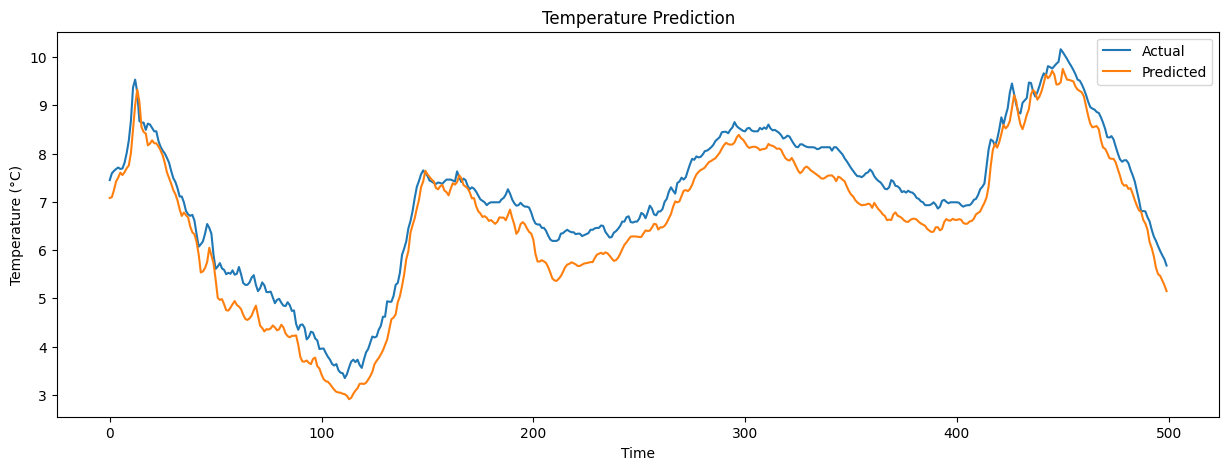

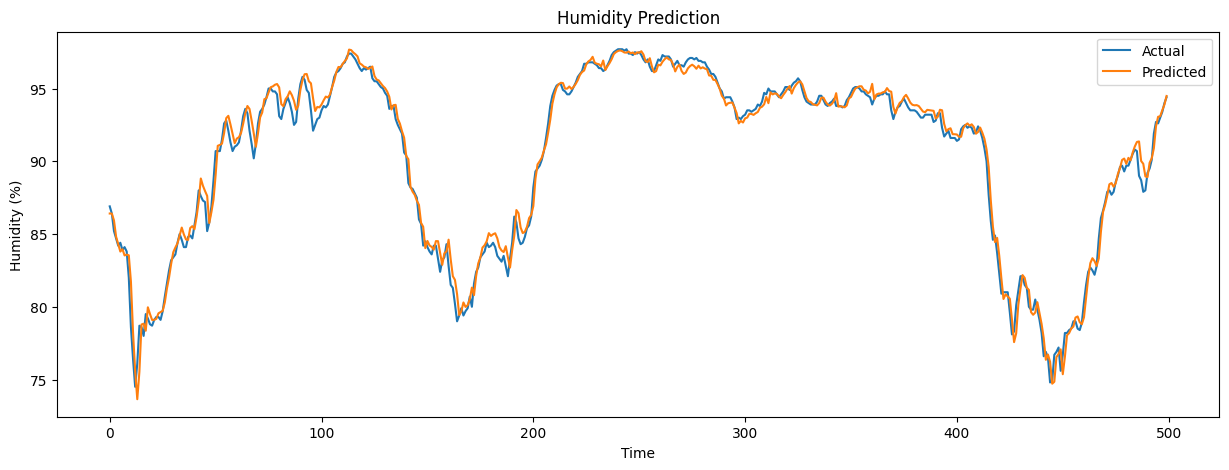

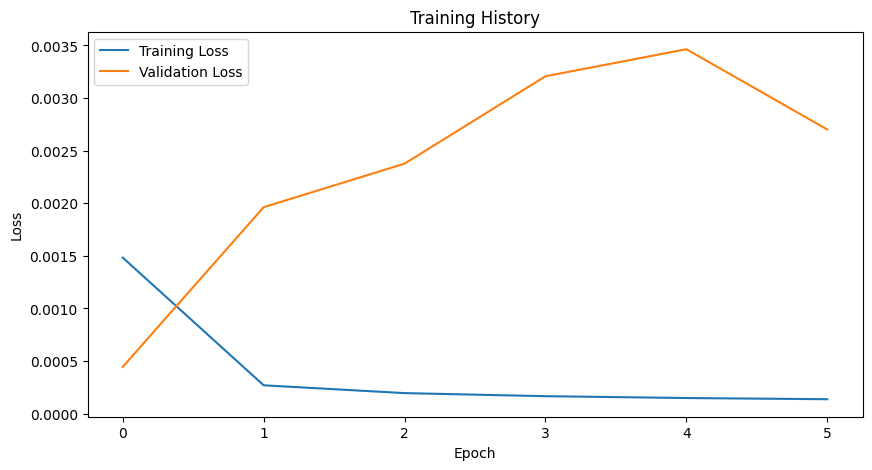

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ================================
# Inverse Transform Predictions
# ================================

temp_idx = train_df.columns.get_loc("T (degC)")
hum_idx = train_df.columns.get_loc("rh (%)")

n_features = train_df.shape[1]

dummy_true = np.zeros((len(y_test), n_features))
dummy_pred = np.zeros((len(y_pred), n_features))

dummy_true[:, temp_idx] = y_test[:, 0]
dummy_true[:, hum_idx] = y_test[:, 1]

dummy_pred[:, temp_idx] = y_pred[:, 0]
dummy_pred[:, hum_idx] = y_pred[:, 1]

true_inverse = scaler.inverse_transform(dummy_true)
pred_inverse = scaler.inverse_transform(dummy_pred)

true_temp = true_inverse[:, temp_idx]
true_hum = true_inverse[:, hum_idx]

pred_temp = pred_inverse[:, temp_idx]
pred_hum = pred_inverse[:, hum_idx]

# ================================
# Metrics
# ================================

temp_mae = mean_absolute_error(true_temp, pred_temp)
temp_rmse = np.sqrt(mean_squared_error(true_temp, pred_temp))
temp_r2 = r2_score(true_temp, pred_temp)

hum_mae = mean_absolute_error(true_hum, pred_hum)
hum_rmse = np.sqrt(mean_squared_error(true_hum, pred_hum))
hum_r2 = r2_score(true_hum, pred_hum)

print("=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)

print("\nTemperature")
print(f"MAE  : {temp_mae:.3f} °C")
print(f"RMSE : {temp_rmse:.3f} °C")
print(f"R²   : {temp_r2:.4f}")

print("\nHumidity")
print(f"MAE  : {hum_mae:.3f} %")
print(f"RMSE : {hum_rmse:.3f} %")
print(f"R²   : {hum_r2:.4f}")

# ================================
# Temperature Plot
# ================================

plt.figure(figsize=(15,5))

plt.plot(true_temp[:500], label="Actual")
plt.plot(pred_temp[:500], label="Predicted")

plt.title("Temperature Prediction")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()

plt.show()

# ================================
# Humidity Plot
# ================================

plt.figure(figsize=(15,5))

plt.plot(true_hum[:500], label="Actual")
plt.plot(pred_hum[:500], label="Predicted")

plt.title("Humidity Prediction")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()

plt.show()

# ================================
# Training Curve
# ================================

plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()